# Chương 8: Mô Hình Sinh (Generative Models)

Chương này tập trung vào **Large Language Models (LLMs)** — các mô hình ngôn ngữ sinh văn bản đạt trình độ gần con người, thậm chí có khả năng suy luận. Đây là bước nhảy vọt lớn nhất của NLP trong thập kỷ gần đây.

**Lịch sử vắn tắt:**
- Shannon (1951): language model ước lượng predictability của text
- N-gram LM: dominant trước 2010
- FFNN LM (Bengio 2003): word embeddings
- Word2Vec (2013): representation learning
- LSTM-based models → Transformer → GPT/BERT → LLMs

---

# 8.1 Giới Thiệu Ngắn Gọn về LLMs

---

## 8.1.1 Decoder-only Transformer

### Bài Toán Language Modeling

$$\Pr(x_0,\ldots,x_m) = \prod_{i=0}^m \Pr(x_i \mid x_0,\ldots,x_{i-1}) \tag{8.1}$$

$$\log\Pr(x_0,\ldots,x_m) = \sum_{i=0}^m \log\Pr(x_i \mid x_0,\ldots,x_{i-1}) \tag{8.2}$$

**Inference — Autoregressive generation:**

$$\hat{x}_i = \arg\max_{x_i \in V} \Pr(x_i \mid x_0,\ldots,x_{i-1}) \tag{8.3}$$

**Ví dụ sinh tuần tự từ prefix $\langle s\rangle$ a:**

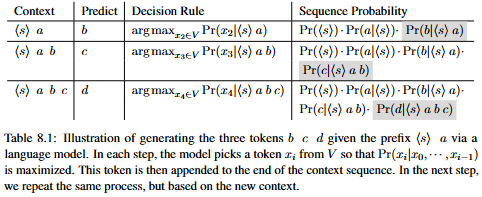

### Kiến Trúc Decoder-only Transformer

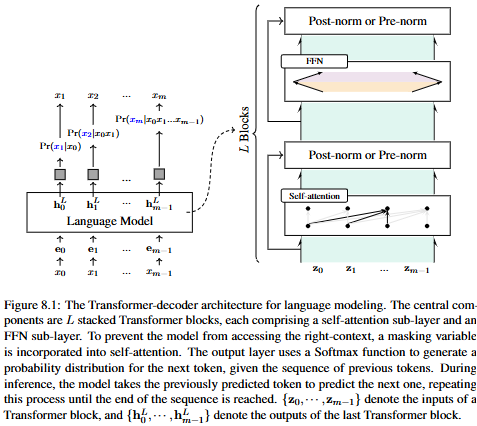

**Input:** Token embeddings + positional embeddings:
$$e_i = x_i + \text{PE}(i)$$

**Mỗi Transformer block** — post-norm hoặc pre-norm:

$$\text{output} = \text{LNorm}(F(\text{input}) + \text{input}) \quad \text{(post-norm)} \tag{8.4}$$

$$\text{output} = F(\text{LNorm}(\text{input})) + \text{input} \quad \text{(pre-norm)} \tag{8.5}$$

**Causal Self-attention với QKV:**

$$\text{Att}_{\text{qkv}}(Q,K,V) = \text{Softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + \text{Mask}\right)V \tag{8.6}$$

$$\text{Mask}(i,k) = \begin{cases}0 & i \geq k \\ -\infty & i < k\end{cases}$$

**Multi-head attention:**

$$F(H) = \text{Merge}(\text{head}_1,\ldots,\text{head}_\tau)W_{\text{head}} \tag{8.7}$$

$$\text{head}_j = \text{Att}_{\text{qkv}}(HW_j^q, HW_j^k, HW_j^v) \tag{8.8}$$

**Output layer — sinh distribution tại mỗi vị trí:**

$$\begin{pmatrix}\Pr(\cdot|x_0)\\\Pr(\cdot|x_0,x_1)\\\vdots\\\Pr(\cdot|x_0,\ldots,x_{m-1})\end{pmatrix} = \text{Softmax}(H^L W_o) \tag{8.12}$$

### Quy Mô Các LLM Hiện Đại

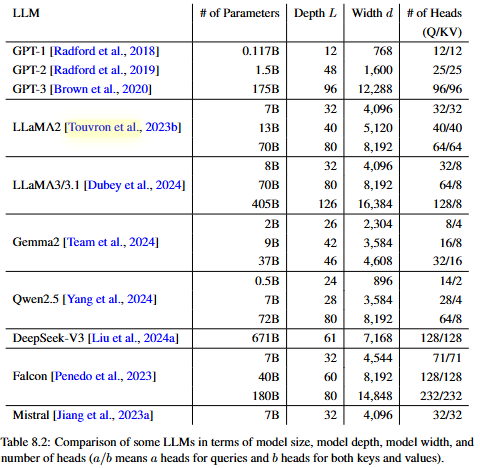

> **Lưu ý:** LLaMA3 dùng **Grouped Query Attention (GQA)** — Q heads nhiều hơn KV heads (32/8 thay vì 32/32) → giảm memory cho KV cache, không ảnh hưởng nhiều đến chất lượng.

---

## 8.1.2 Training LLMs

**Hàm mục tiêu — Maximum Likelihood Estimation:**

$$\mathcal{L}_\theta(x) = \sum_{i=1}^m \log\Pr_\theta(x_i \mid x_0,\ldots,x_{i-1}) \tag{8.13}$$

$$\hat{\theta} = \arg\max_\theta \sum_{x \in D} \mathcal{L}_\theta(x) \tag{8.14}$$

**Các thách thức khi scale lên:**
- Cần hàng trăm đến hàng nghìn GPUs
- Distributed training phức tạp (data/model/pipeline parallelism)
- Training instability tăng với depth và parameter count
- Chi phí cực kỳ lớn → mỗi run training rất đắt đỏ

---

## 8.1.3 Fine-tuning LLMs

**Framework inference:**

$$\hat{y} = \arg\max_y \sum_{i=1}^n \log\Pr(y_i \mid x_0,\ldots,x_m, y_1,\ldots,y_{i-1}) \tag{8.15}$$

$x$ = context (input của user), $y$ = generated response.

**Prompting với templates:**

```
Task: Grammaticality check
Template: {*sentence*}
          Question: Is this sentence grammatically correct?
          Answer: [generate here]

Task: Translation
Template: {*sentence*}
          Translate this sentence from English into Chinese.
          
Code-style: [src-lang] = English [tgt-lang] = Chinese
            [input] = {*sentence*} [output] =
```

**Instruction Fine-tuning:** Fine-tune LLM trên instruction-following data → model học cách follow instructions, không chỉ predict next token.

---

## 8.1.4 Alignment qua RLHF

### Vấn Đề

Pre-trained LLM có thể generate harmful, biased, hoặc unhelpful content. Cần **align** model với human values và preferences.

**Tại sao không dùng supervised learning đơn thuần?**
- Rất khó để humans viết "perfect" output cho mọi input
- Dễ hơn nhiều để humans **so sánh** hai outputs → preference
- RLHF khai thác preference data hiệu quả hơn

### Hai Thành Phần RLHF

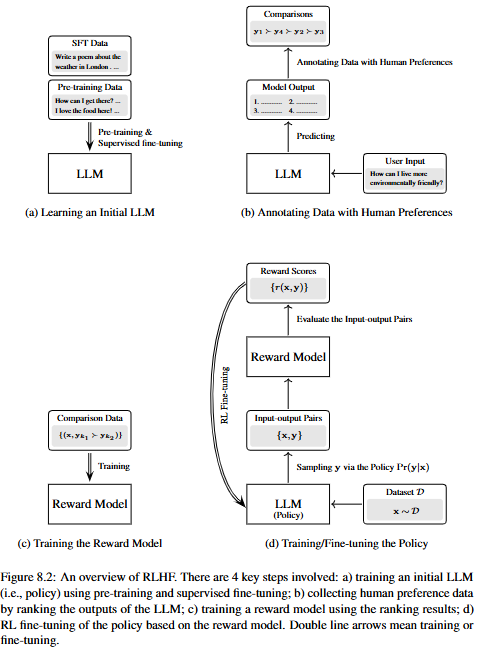

**Agent:** LLM cần optimize — policy $\Pr(y|x)$

**Reward Model:** Proxy cho human preferences — đánh giá quality của output, gán numerical score $R(x,y)$.

### Quy Trình RLHF

**Bước 1 — Build initial policy:**
Pre-training + Instruction fine-tuning (SFT)

**Bước 2 — Thu thập human feedback:**

Dùng policy sinh $K$ outputs $\{y_1,\ldots,y_K\}$ cho mỗi input, humans rank chúng:

Ví dụ với input "How can I live a more environmentally friendly life?":
```
y₁: Consider switching to electric vehicle...
y₂: Adopt a minimalist lifestyle...
y₃: Go off-grid. Generate your own renewable energy...
y₄: Support local farm products...

Ranking: y₁ ≻ y₄ ≻ y₂ ≻ y₃
```
Dễ rank hơn là assign absolute score.

**Bước 3 — Train Reward Model:**

Reward model có cùng architecture với LLM nhưng nhỏ hơn. Tạo sequence $\text{seq}_k = [x, y_k]$, lấy output tại token cuối làm representation → linear layer → reward score $R_\omega(x, y_k)$.

**Pairwise ranking loss:**

$$\text{Loss}_\omega(D_r) = -\mathbb{E}_{(x,y_{k_1},y_{k_2})\sim D_r} \log\!\left(\text{Sigmoid}(R_\omega(x,y_{k_1}) - R_\omega(x,y_{k_2}))\right) \tag{8.19}$$

Nếu $y_{k_1} \succ y_{k_2}$: muốn $R_\omega(x,y_{k_1}) > R_\omega(x,y_{k_2})$ → Sigmoid dương → loss nhỏ.

**Bước 4 — Policy Learning (RL Fine-tuning):**

$$\tilde{\theta} = \arg\max_{\hat{\theta}+} \mathbb{E}_{(x,y_{\hat{\theta}+})\sim D_{\text{rlft}}} R_{\hat{\omega}}(x, y_{\hat{\theta}+}) \tag{8.22}$$

Trong thực tế dùng **PPO (Proximal Policy Optimization)** để ổn định training.

**Ưu điểm RLHF:**
- Khai thác preference (so sánh) thay vì absolute labels
- Khả năng explore space của samples → tìm behaviors không có trong labeled data
- Reward model cung cấp continuous supervision signal

---

## 8.1.5 Prompting LLMs

### Role Assignment

```
Please explain what delayed gratification is.
Note, you are a researcher with a deep background in psychology...

[Model output:]
Delayed gratification is the process of resisting an immediate reward 
in anticipation of receiving a more valuable reward in the future...
```

### Code Debugging

```
Fix the bugs in this C language program.
#include <stdio.h>
int main() {
    printg("Hello, World!")
    return 0;
}

[Model output:]
1. 'printg' → 'printf'
2. Missing semicolon after printf call.

Corrected:
    printf("Hello, World!");
```

### Conversational AI

```
Hi! I'm an assistant. How can I help you?
Who won the FIFA World Cup 2022?
Argentina won the FIFA World Cup 2022.
Where was it held?
The 2022 FIFA World Cup was held in Qatar.
How many times has Argentina won the World Cup?
Argentina has won the FIFA World Cup three times.
```

---

### In-Context Learning (ICL) và Chain-of-Thought (CoT)

**Vấn đề với complex reasoning:**

```
Jack has 7 apples. He ate 2 for dinner, his mom gave him 5 more. 
Next day, he gave 3 to John. How many apples does Jack have?

[Model output without CoT:] The answer is 10.  ← SAI
```

**Few-shot ICL đơn giản vẫn sai:**
```
Tom has 12 marbles... [solution] The answer is 17.
Jack has 7 apples... [Model] The answer is 12.  ← SAI
```

**Chain-of-Thought (CoT) Prompting — Wei et al. 2022:**

Thêm **reasoning steps** vào demonstration:

```
Tom has 12 marbles. He wins 7 more... [demonstration với reasoning]
Tom initially has 12 marbles. After winning, 12+7=19. He loses 5: 19-5=14. 
Brother gives 3: 14+3=17. Therefore, Tom has 17 marbles. So the answer is 17.

Jack has 7 apples... [model follows same pattern]
Jack starts with 7 apples. He eats 2: 7-2=5. Mom gives 5: 5+5=10.
He gives 3 to John: 10-3=7. Therefore, Jack has 7 apples. So the answer is 7. ✓
```

**Zero-shot CoT (Kojima et al. 2022):**

Chỉ cần thêm "Let's think step by step." — không cần demonstration:

```
Jack has 7 apples. He ate 2 for dinner, his mom gave him 5 more.
Next day, he gave 3 to John. How many apples does Jack have?
Let's think step by step.

[Model output:]
1. Initial: Jack starts with 7 apples.
2. After dinner: 7-2 = 5 apples.
3. Mom gives 5: 5+5 = 10 apples.
4. Give to John: 10-3 = 7 apples.
Jack has 7 apples left.  ✓
```

### Các Phương Pháp Prompting

| Phương pháp | Mô tả | Khi dùng |
|---|---|---|
| **Zero-shot** | Chỉ instruction, không có demonstration | Task đơn giản, LLM mạnh |
| **One-shot** | 1 demonstration | Task cần ví dụ format |
| **Few-shot** | $k$ demonstrations | Task phức tạp, cần pattern |
| **Zero-shot CoT** | "Let's think step by step" | Reasoning tasks |
| **Few-shot CoT** | Demonstrations với reasoning steps | Complex multi-step reasoning |
| **Role assignment** | Gán role chuyên gia | Cần domain expertise |

---

## Tổng Kết Mục 8.1

```
LLM Architecture:
  Decoder-only Transformer (causal mask)
  L blocks × (Causal Self-Attn + FFN)
  Softmax(H^L · Wo) → Pr(next token)
  
Training:
  MLE: max Σ log Pr(xᵢ|x₀...xᵢ₋₁)
  Scale: data × params → better performance (scaling laws)

Fine-tuning pipeline:
  Pre-training → SFT (instruction) → RLHF alignment
  
  RLHF:
    Human ranks outputs → Reward Model (ranking loss)
    RL fine-tune policy to max R(x,y) → PPO

Prompting:
  Templates: instruction + placeholder → LLM completes
  Zero-shot: just instruction
  Few-shot ICL: demonstrate input→output mapping
  CoT: show reasoning steps → better at multi-step problems
  Zero-shot CoT: "Let's think step by step."
```

# 8.2 Training at Scale

---

## 8.2.1 Chuẩn Bị Dữ Liệu (Data Preparation)

LLMs cần lượng dữ liệu khổng lồ — hàng nghìn tỷ tokens:

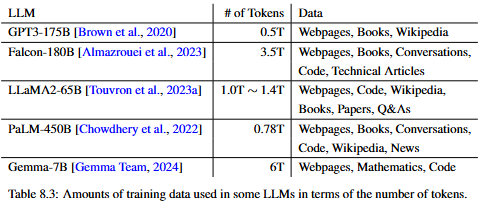

**Bốn vấn đề chính:**

**1. Chất lượng dữ liệu:** Web scraping chứa errors, toxic content, fabricated facts. Penedo et al. (2023): 90% web data có thể loại bỏ sau filtering. Cần rigorous filtering/cleaning pipeline.

**2. Đa dạng dữ liệu:** Nhiều domain → model adapt tốt hơn. Thú vị: code trong training data **cải thiện reasoning** tổng quát, đặc biệt với CoT prompting. Multilingual data → một model nhiều ngôn ngữ.

**3. Bias trong dữ liệu:** Gender bias, cultural bias (English-centric → Western values). Giải pháp: balance demographic categories, tăng diversity ngôn ngữ/văn hóa.

**4. Privacy:** LLMs có thể memorize và reproduce sensitive information. Giải pháp: anonymization, remove PII, fine-tune để reject sensitive requests.

---

## 8.2.2 Cải Tiến Kiến Trúc Model

Training LLM lớn → **training instability** tăng. Các modification quan trọng:

### 1. Layer Normalization

**Standard LayerNorm:**

$$\text{LNorm}(h) = \alpha \odot \frac{h - \mu}{\sigma + \varepsilon} + \beta \tag{8.23}$$

**RMSNorm** (LLaMA series) — chỉ rescale, không re-center:

$$\text{RMSNorm}(h) = \alpha \odot \frac{h}{\sigma_{\text{rms}} + \varepsilon}, \quad \sigma_{\text{rms}} = \sqrt{\frac{1}{d}\sum_{k=1}^d h_k^2} \tag{8.24}$$

**Ưu điểm RMSNorm:** Đơn giản hơn, ít tham số hơn, training ổn định tương đương.

**Pre-norm vs Post-norm:** Hầu hết LLMs hiện đại dùng **pre-norm** → gradient flow tốt hơn cho mạng rất sâu (Mục 6.3.2).

### 2. Activation Functions trong FFN

**Standard FFN:**

$$\text{FFN}(h) = \sigma(hW_h + b_h)W_f + b_f \tag{8.25}$$

**ReLU** — cơ bản:

$$\sigma_{\text{relu}}(h) = \max(0, h) \tag{8.26}$$

**GeLU** (BERT, GPT-3, BLOOM) — smooth approximation của ReLU:

$$\sigma_{\text{gelu}}(h) = h \odot \Phi(h) \tag{8.27}$$

$\Phi(h)$ là CDF của $\mathcal{N}(0,1)$ — weight mỗi input theo xác suất nó dương → mượt hơn ReLU.

**Gated Linear Unit (GLU) family:**

$$\sigma_{\text{glu}}(h) = \sigma(hW_1 + b_1) \odot (hW_2 + b_2) \tag{8.28}$$

Hai biến thể phổ biến:

**GeGLU** (Gemma):

$$\sigma_{\text{geglu}}(h) = \sigma_{\text{gelu}}(hW_1 + b_1) \odot (hW_2 + b_2) \tag{8.29}$$

**SwiGLU** (PaLM, LLaMA series) — dùng Swish activation:

$$\sigma_{\text{swiglu}}(h) = \sigma_{\text{swish}}(hW_1 + b_1) \odot (hW_2 + b_2) \tag{8.30}$$

với $\sigma_{\text{swish}}(h) = h \odot \text{Sigmoid}(ch)$.

**Ưu điểm GLU:** Gate mechanism kiểm soát thông tin → biểu diễn tốt hơn với cùng số tham số.

### 3. Bỏ Bias Terms

$$\text{FFN}(h) = \sigma(hW_h)W_f \tag{8.31}$$

Bỏ bias trong LayerNorm, QKV projections, FFN → **cải thiện training stability** (Chowdhery et al., 2022). Dùng trong LLaMA, Gemma.

### So Sánh Kiến Trúc Các LLMs

| Thành phần | Standard Transformer | LLMs hiện đại (LLaMA, Gemma) |
|---|---|---|
| Norm | Post-norm LayerNorm | **Pre-norm RMSNorm** |
| Activation | ReLU | **SwiGLU / GeGLU** |
| Bias | Có | **Không** |
| Positional | Sinusoidal (absolute) | **RoPE** (Mục 8.3) |

---

## 8.2.3 Distributed Training

Training LLMs đòi hỏi hàng trăm đến hàng nghìn GPUs. Bốn loại parallelism:

### 1. Data Parallelism

Chia minibatch $D_{\text{mini}}$ thành $N$ batches nhỏ, mỗi worker tính gradient riêng, aggregate lại:

$$\frac{\partial L_{\theta_t}(D_{\text{mini}})}{\partial\theta_t} = \underbrace{\frac{\partial L(D_1)}{\partial\theta_t}}_{\text{worker 1}} + \underbrace{\frac{\partial L(D_2)}{\partial\theta_t}}_{\text{worker 2}} + \cdots + \underbrace{\frac{\partial L(D_N)}{\partial\theta_t}}_{\text{worker N}} \tag{8.33}$$

Mỗi worker chạy **toàn bộ model** → cần model fit vào memory của một device. Speedup lý tưởng: $N\times$.

### 2. Model Parallelism

Khi model quá lớn cho một device → chia layers ra nhiều workers:

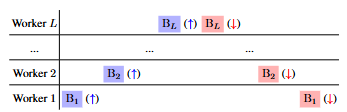

```
Worker L:  BL(↑)  BL(↓)
Worker 2:  B2(↑)  B2(↓)
Worker 1:  B1(↑)  B1(↓)
           forward backward
```

**Hạn chế:** Workers phải chạy tuần tự → idle time nhiều. Thường kết hợp với parallelism khác.

### 3. Tensor Parallelism

Chia **ma trận tham số** thành chunks, mỗi device tính một phần:

$$hW_h = h\begin{bmatrix}W_h^1 & W_h^2 & \cdots & W_h^M\end{bmatrix} = \begin{bmatrix}hW_h^1 & hW_h^2 & \cdots & hW_h^M\end{bmatrix} \tag{8.34, 8.35}$$

Thực hiện $M$ phép nhân ma trận song song trên $M$ devices. Phù hợp với GPU architecture (tile-based parallel algorithms).

### 4. Pipeline Parallelism

Giải quyết idle time của model parallelism bằng **micro-batches**:

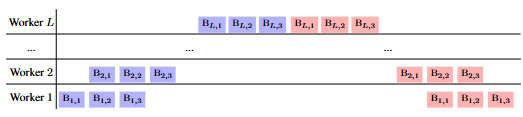

```
Worker L:  BL,1  BL,2  BL,3 | BL,1  BL,2  BL,3
Worker 2:  B2,1  B2,2  B2,3 | B2,1  B2,2  B2,3
Worker 1:  B1,1  B1,2  B1,3 | B1,1  B1,2  B1,3
           ←── forward ───→ | ←── backward ──→
```

$B_{l,k}$ = processing micro-batch $k$ tại worker $l$. Micro-batches chồng lên nhau → giảm idle time.

**Thách thức của distributed training:**
- **Communication overhead:** Synchronize gradients qua network tốn thời gian
- **Synchronization cost:** Phải chờ worker chậm nhất
- **Fault tolerance:** Node crash → restart từ checkpoint
- **Mixed precision:** FP16/FP8 cho gradients + FP32 cho parameter update → numerical stability issues

---

## 8.2.4 Scaling Laws

### Hiện Tượng

Scaling laws mô tả quan hệ giữa **performance** và **training resources** (data size $D$, model size $N$, compute $C$).

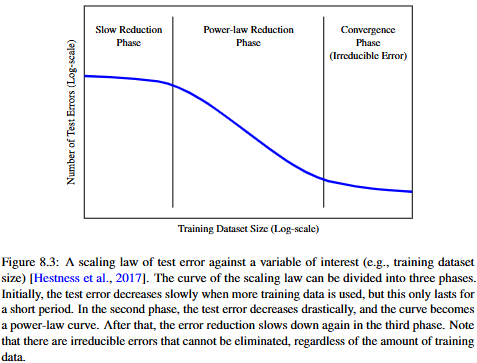

**Ba giai đoạn:**
1. **Slow Reduction:** Ban đầu ít data/params → cải thiện chậm
2. **Power-law:** Tăng tốc theo power-law
3. **Convergence:** Diminishing returns → irreducible error $\varepsilon_\infty$

### Các Công Thức Scaling Law

**Power law đơn giản:**

$$L(x) = ax^b \tag{8.36}$$

**Với irreducible error:**

$$L(x) = ax^b + \varepsilon_\infty \tag{8.37}$$

**Kaplan et al. (2020)** — OpenAI:

$$L(N) = \left(\frac{N}{8.8\times10^{13}}\right)^{-0.076}, \quad L(D) = \left(\frac{D}{5.4\times10^{13}}\right)^{-0.095}$$

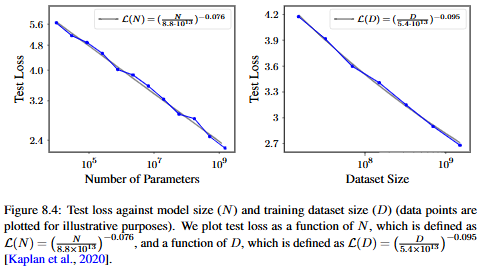

**Chinchilla Scaling Law (Hoffmann et al., 2022)** — DeepMind:

$$L(N, D) = \underbrace{\frac{406.4}{N^{0.34}}}_{\text{model scaling}} + \underbrace{\frac{410.7}{D^{0.28}}}_{\text{data scaling}} + \underbrace{1.69}_{\text{irreducible}} \tag{8.39}$$

**Kết luận Chinchilla:** Để optimal performance với fixed compute, cần **balance** giữa model size và data size — nhiều LLMs trước đó quá lớn so với lượng data → cần train nhỏ hơn nhưng với nhiều data hơn.

**Rosenfeld et al. (2020):**

$$L(N, D) = aN^b + cD^d + \varepsilon_\infty \tag{8.38}$$

### Emergent Abilities

Khi scale đủ lớn, LLMs xuất hiện các khả năng **không thể dự đoán** từ scaling laws:
- Few-shot learning
- Chain-of-thought reasoning
- Code generation
- Multilingual translation không cần fine-tuning

**Ý nghĩa:** Nếu vẫn đang trong vùng power-law, tiếp tục scale là hướng đi đúng.

**Lưu ý quan trọng:** Test loss thấp hơn **không luôn** có nghĩa là performance tốt hơn trên mọi downstream task — fine-tuning và prompting ảnh hưởng đến kết quả cuối cùng.

---

## Tổng Kết Mục 8.2

```
Data Preparation:
  Trillions of tokens từ web + books + code + ...
  Issues: quality, diversity, bias, privacy
  → Filtering, deduplication, anonymization

Model Modifications cho stable training:
  Norm: Pre-norm RMSNorm (thay Post-norm LayerNorm)
  Activation: SwiGLU/GeGLU (thay ReLU)
  Bias: Remove for stability
  Pos encoding: RoPE (Mục 8.3)

Distributed Training:
  Data Parallelism:    chia data → N× speedup
  Model Parallelism:   chia layers → sequential
  Tensor Parallelism:  chia ma trận → parallel ops
  Pipeline Parallelism: micro-batches → overlap forward/backward

Scaling Laws:
  L(N,D) = aN^b + cD^d + ε∞    (Chinchilla)
  Power-law behavior → scale lên vẫn hiệu quả
  Emergent abilities xuất hiện khi đủ lớn
```

| Parallelism | Chia gì | Speedup | Hạn chế |
|---|---|---|---|
| Data | Minibatch | Gần $N\times$ | Cần model fit 1 device |
| Model | Layers | Dùng nhiều devices | Workers idle nhiều |
| Tensor | Ma trận params | Song song ops | Communication overhead |
| Pipeline | Micro-batches | Giảm idle time | Micro-batch size trade-off |

Để tổng hợp đúng và đầy đủ, hãy để tôi đọc file trước.Giờ tôi đã đọc đầy đủ toàn bộ phần 8.3. Bắt đầu tổng hợp lại hoàn chỉnh:

---

# 8.3 Mô Hình Hóa Chuỗi Dài (Long Sequence Modeling)

**Ba loại bài toán:**
- **Long-context generation** ($x$ dài, $y$ ngắn): tóm tắt tài liệu dài
- **Long-text generation** ($x$ ngắn, $y$ dài): viết truyện từ vài từ khóa
- **Long-context + long-text** (cả hai dài): dịch tài liệu dài

**Hai hướng nghiên cứu:**
1. Kiến trúc/training hiệu quả hơn (đã bàn ở Ch.6)
2. Adapt pre-trained LLMs cho chuỗi dài với ít/không fine-tuning ← **focus chính của mục này**

---

## 8.3.1 Tối Ưu Từ Góc Độ HPC

**Reduced precision:** FP32 → FP16/BF16/INT8 → tăng throughput, giảm memory.

**IO-aware implementations:** FlashAttention, PagedAttention — tối ưu memory access pattern (Mục 6.4.9).

### Sequence Parallelism

Chia $K$ và $V$ theo chiều sequence, giao cho $n_u$ nodes xử lý song song:

$$\text{Att}(q_i, K, V) = \sum_{j=0}^{m-1} \alpha_{i,j} v_j \tag{8.40}$$

$$\beta_{i,j} = \frac{q_i \cdot k_j}{\sqrt{d}} + \text{Mask}(i,j) \tag{8.41}$$

$$\alpha_{i,j} = \text{Softmax}(\beta_{i,j}) = \frac{\exp(\beta_{i,j})}{\sum_{j'} \exp(\beta_{i,j'})} \tag{8.42}$$

**Thách thức:** Denominator của Softmax cần sum qua **tất cả** $j'$ — phải communicate giữa nodes:

$$\alpha_{i,j} = \frac{\exp(\beta_{i,j})}{\underbrace{\sum_{k_{j'}\in K^{[1]}}\exp(\beta_{i,j'})}_{\text{node 1}} + \cdots + \underbrace{\sum_{k_{j'}\in K^{[n_u]}}\exp(\beta_{i,j'})}_{\text{node }n_u}} \tag{8.43}$$

Dùng **all-reduce operation** để thu thập kết quả từ các nodes → tính denominator chính xác.

**Tính attention output song song:**

$$\text{Att}(q_i, K, V) = \underbrace{\sum_{v_{j'}\in V^{[1]}} \alpha_{i,j'} v_{j'}}_{\text{node 1}} + \cdots + \underbrace{\sum_{v_{j'}\in V^{[n_u]}} \alpha_{i,j'} v_{j'}}_{\text{node }n_u} \tag{8.44}$$

Reduce operation tổng hợp kết quả từ các nodes.

---

## 8.3.2 Kiến Trúc Hiệu Quả

**Hai vấn đề:**
- Standard self-attention: $O(m^2)$ time và memory
- KV cache tăng tuyến tính theo $m$ → prohibitive với chuỗi rất dài

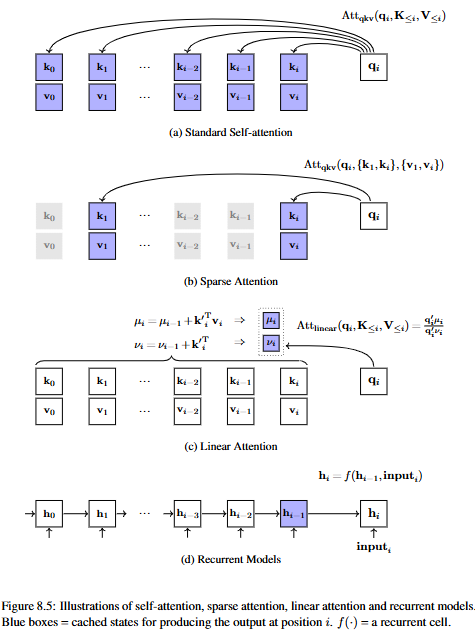

### (a) Standard Self-attention

$$\text{Att}(Q, K, V) = \alpha(Q, K) V, \quad \alpha(Q,K) = \text{Softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + \text{Mask}\right) \tag{8.45, 8.46}$$

Ma trận $\alpha \in \mathbb{R}^{m\times m}$ — lower triangular (causal). Output tại $i$:

$$\text{Att}(q_i, K_{\leq i}, V_{\leq i}) = \sum_{j=0}^{i} \alpha_{i,j} v_j \tag{8.47}$$

### (b) Sparse Attention

Chỉ tính attention với subset $G \subseteq \{0,\ldots,i\}$:

$$\text{Att}_{\text{sparse}}(q_i, K_{\leq i}, V_{\leq i}) = \sum_{j \in G} \alpha'_{i,j} v_j \tag{8.48}$$

$\alpha'_{i,j}$ normalize trên $G$ → $\alpha'_{i,j} > \alpha_{i,j}$.

**Hạn chế:** Vẫn cần lưu **toàn bộ** KV cache — chỉ giảm compute, không giảm memory bottleneck.

### (c) Linear Attention

Map queries/keys qua kernel $\phi(\cdot)$: $q'_i = \phi(q_i)$, $k'_i = \phi(k_i)$:

$$\text{Att}_{\text{linear}}(q'_i, K'_{\leq i}, V_{\leq i}) = \frac{q'_i \mu_i}{q'_i \nu_i} \tag{8.49}$$

**Tính recurrently — không cần lưu KV cache:**

$$\mu_i = \mu_{i-1} + k_i^{'\top} v_i \tag{8.50}$$
$$\nu_i = \nu_{i-1} + k_i^{'\top} \tag{8.51}$$

$\mu_i, \nu_i$ là summary vectors của toàn bộ history với **kích thước cố định** → chi phí $O(1)$ mỗi bước.

### (d) Recurrent Models (Mamba/SSM)

$$h_i = f(h_{i-1}, \text{input}_i)$$

Fixed-size state $h_i$ — không lưu lịch sử. Modern State Space Models (SSM) như **Mamba** đang hồi sinh như alternative mạnh mẽ cho Transformer trong long sequence modeling.

---

## 8.3.3 Cache và Memory

### 1. Fixed-size KV Cache

**Framework tổng quát:**

$$\text{Att}(q_i, \text{Mem}) = \text{Att}_{\text{qkv}}(q_i, K_{\leq i}, V_{\leq i}) \tag{8.52}$$

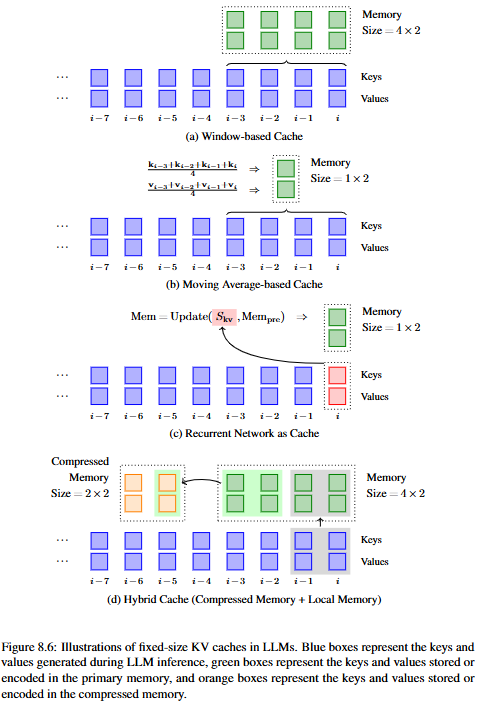

**Phương án 1 — Sliding Window (Local Attention):**

$$\text{Mem} = (K_{[i-n_c+1,\ i]},\ V_{[i-n_c+1,\ i]}) \tag{8.53}$$

Chỉ giữ $n_c$ tokens gần nhất → memory $O(n_c \cdot d)$ cố định.

**Phương án 2 — Unweighted Moving Average:**

$$\text{Mem} = \left(\frac{\sum_{j=i-n_c+1}^{i} k_j}{n_c},\ \frac{\sum_{j=i-n_c+1}^{i} v_j}{n_c}\right) \tag{8.54}$$

Nén $n_c$ vectors thành **1 summary vector** → memory $O(d)$.

**Phương án 3 — Weighted Moving Average** (gần hơn → weight lớn hơn):

$$\text{Mem} = \left(\frac{\sum_{j=i-n_c+1}^{i} \beta_{j-i+n_c} k_j}{\sum_{j=1}^{n_c} \beta_j},\ \frac{\sum_{j=i-n_c+1}^{i} \beta_{j-i+n_c} v_j}{\sum_{j=1}^{n_c} \beta_j}\right) \tag{8.55}$$

với $\beta_1 < \beta_2 < \cdots < \beta_{n_c}$.

**Phương án 4 — Cumulative Average** (summary toàn bộ history):

$$\text{Mem} = \left(\frac{\sum_{j=0}^{i} k_j}{i+1},\ \frac{\sum_{j=0}^{i} v_j}{i+1}\right) \tag{8.56}$$

**Dạng recurrent** — chỉ cần lưu 1 cặp $(k,v)$:

$$\text{Mem}_i = \frac{(k_i, v_i) + i \cdot \text{Mem}_{i-1}}{i+1} \tag{8.57}$$

**Phương án 5 — Neural Network Memory:**

$$\text{Mem} = \text{Update}(S_{kv}, \text{Mem}_{\text{pre}}) \tag{8.58}$$

Trường hợp đặc biệt — RNN-like:

$$\text{Mem} = f((k_i, v_i), \text{Mem}_{\text{pre}}) \tag{8.59}$$

Trường hợp FIFO (Transformer-XL style):

$$\text{Mem} = \text{FIFO}(S_{kv}, \text{Mem}_{\text{pre}}) \tag{8.60}$$

Giữ 2 segments — current và previous → cross-chunk attention.

**Phương án 6 — Compressive Transformer** (dual memory):

Mem = local (raw KV), CMem = compressed long-term:

$$\text{Att}_{\text{com}}(q_i, \text{Mem}, \text{CMem}) = \text{Att}_{\text{qkv}}(q_i, [\text{Mem}, \text{CMem}]) \tag{8.61}$$

Update local memory:

$$\text{Mem} = \text{FIFO}(S^k_{kv}, \text{Mem}_{\text{pre}}) \tag{8.62}$$

Khi ejected từ Mem → compress $n_s$ pairs → $n_s/c$ pairs → đưa vào CMem:

$$\text{CMem} = \text{FIFO}(C^k_{kv}, \text{CMem}_{\text{pre}}) \tag{8.63}$$

**Triết lý:** Local context → biểu diễn đầy đủ; long-range context → có thể compress.

**Global tokens:** Thêm vài tokens đặc biệt đầu chuỗi vào attention → **attention sink** — hấp thụ attention scores dư thừa, ổn định performance với context rất dài.

---

### 2. External Memory — k-NN và RAG

**k-NN Augmented Attention:**

$$\text{Att}(q_i, \text{Mem}, \text{Mem}_{\text{knn}}) = g \odot \text{Att}_{\text{local}} + (1-g) \odot \text{Att}_{\text{knn}} \tag{8.64}$$

$$\text{Att}_{\text{local}} = \text{Att}(q_i, \text{Mem}), \quad \text{Att}_{\text{knn}} = \text{Att}(q_i, \text{Mem}_{\text{knn}}) \tag{8.65, 8.66}$$

$g \in \mathbb{R}^d$ = learned gate. k-NN truy xuất từ **vector database** bên ngoài.

**k-NN Language Modeling:**

Datastore lưu các tuple $(z, w)$ — ($z$ = hidden state, $w$ = next token). Khi inference, retrieve $k$ nearest neighbors theo $h_i$:

$$\Pr_{\text{knn}}(v \mid h_i) \propto \sum_{\substack{(z_j, w_j) \in \text{top-k} \\ w_j = v}} \exp(-d(h_i, z_j)) \tag{8.67}$$

Interpolate với LM distribution:

$$\Pr(\cdot \mid h_i) = \lambda \cdot \Pr_{\text{knn}}(\cdot \mid h_i) + (1-\lambda) \cdot \Pr_{\text{lm}}(\cdot \mid h_i) \tag{8.68}$$

**Retrieval-Augmented Generation (RAG):**

$$x' = g(c_1, \ldots, c_k, x) \tag{8.69}$$

1. Dùng $x$ làm query → retrieve $k$ document chunks $\{c_1,\ldots,c_k\}$ từ datastore
2. Ghép với prompt template $g(\cdot)$ → augmented input $x'$
3. LLM dự đoán $\Pr(y \mid x')$

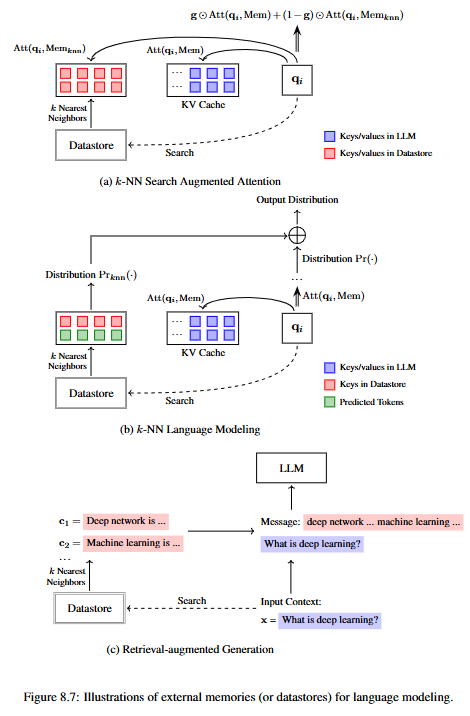

**Ưu điểm RAG:** Không thay đổi LLM architecture; update knowledge base mà không retrain model.

---

### 3. Memory Capacity

**Trade-off cốt lõi:**

| Memory Model | Capacity | Chi phí |
|---|---|---|
| Standard KV cache | Unbounded (tăng với $i$) | $O(i \cdot d)$ |
| Sliding window | Giới hạn $n_c$ tokens | $O(n_c \cdot d)$ |
| Moving average | 1 summary vector | $O(d)$ |
| Vector database (RAG) | Effectively unbounded | Overhead retrieval |
| Recurrent state | Fixed | $O(d_{\text{state}})$ |

**Streaming context:** Context tăng vô hạn → recurrent models phù hợp hơn (fixed-size state); RAG phù hợp cho static context.

---

## 8.3.4 Chia Sẻ Giữa Heads và Layers

KV cache tổng thể: $O(L \cdot \tau \cdot d_h \cdot m)$. Ngoài giảm $m$, có thể giảm theo chiều $\tau$.

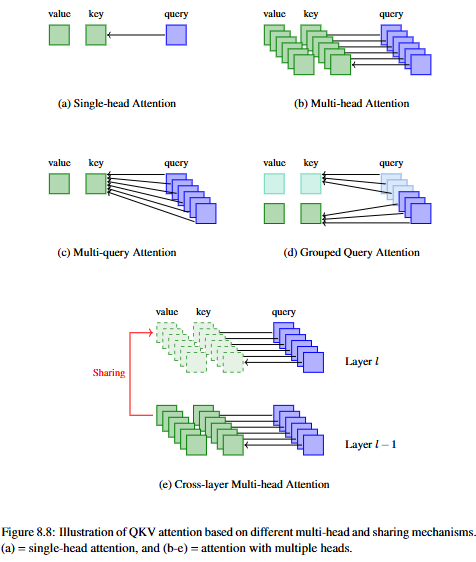

**Multi-head Attention (MHA) — standard:**

$$\text{head}_j = \text{Att}_{\text{qkv}}(q_i^{[j]}, K_{\leq i}^{[j]}, V_{\leq i}^{[j]}) \tag{8.71}$$

KV cache: $O(L \cdot \tau \cdot d_h \cdot m)$.

**Multi-Query Attention (MQA) — Shazeer 2019:**

$$\text{head}_j = \text{Att}_{\text{qkv}}(q_i^{[j]}, K_{\leq i}, V_{\leq i}) \tag{8.72}$$

Tất cả $\tau$ heads **dùng chung 1 cặp** $(K, V)$ → KV cache: $O(L \cdot d_h \cdot m)$ — giảm $\tau$ lần.

**Grouped Query Attention (GQA) — Ainslie et al. 2023:**

$$\text{head}_j = \text{Att}_{\text{qkv}}(q_i^{[j]}, K_{\leq i}^{[g(j)]}, V_{\leq i}^{[g(j)]}) \tag{8.73}$$

Chia $\tau$ heads thành $n_g$ groups, mỗi group chia sẻ 1 cặp $(K, V)$ → KV cache: $O(L \cdot n_g \cdot d_h \cdot m)$.

**Hai trường hợp đặc biệt của GQA:**
- $n_g = \tau$: GQA = MHA (standard)
- $n_g = 1$: GQA = MQA

**Cross-layer Attention:** Query tại layer $l$ attend vào KV cache của layer $l-1$ → chia sẻ cache **across layers** → giảm memory theo chiều $L$.

**So sánh:**

| Phương pháp | KV Cache | Expressiveness | Ví dụ |
|---|---|---|---|
| MHA | $O(L \cdot \tau \cdot d_h \cdot m)$ | Cao nhất | BERT, GPT-2 |
| GQA | $O(L \cdot n_g \cdot d_h \cdot m)$ | Trung bình | LLaMA3 (32Q/8KV) |
| MQA | $O(L \cdot d_h \cdot m)$ | Thấp nhất | PaLM |

---

## 8.3.5 Position Extrapolation và Interpolation

### Vấn Đề Cơ Bản

$$e_i = x_i + \text{PE}(i) \tag{8.74}$$

LLM train trên $[0, m_l]$ → inference cần $m \gg m_l$ → positions ngoài training range.

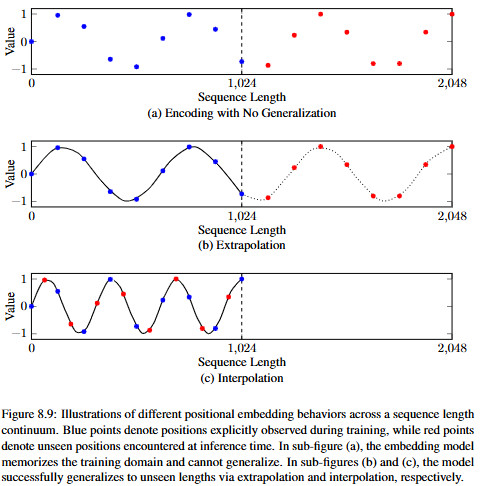

**Hai chiến lược tổng quát:**
- **Extrapolation:** Dùng trực tiếp ngoài training range (model cần học hàm tổng quát hóa)
- **Interpolation:** Map range lớn hơn vào original range đã train

### 1. Attention with Learnable Biases (T5 và ALiBi)

Thêm relative positional bias vào attention scores:

$$\text{Att}(Q, K, V) = \text{Softmax}\!\left(\frac{QK^\top}{\sqrt{d}} + \text{PE}(i,j)\right)V$$

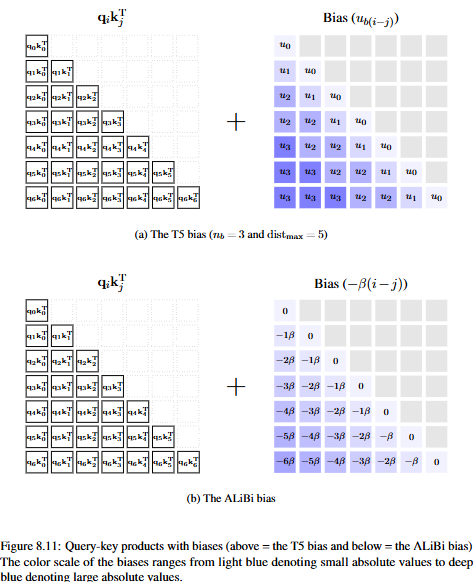

**T5 Bias:** $\text{PE}(i,j) = u_{b(i-j)}$ — scalar learned cho mỗi distance bucket. Bucket gần: phân biệt chi tiết; bucket xa: gộp chung.

**ALiBi (Attention with Linear Biases):** $\text{PE}(i,j) = -\beta(i-j)$ — linear penalty tuyến tính, không cần học:

```
ALiBi bias matrix (β = 1):
 0   -∞   -∞   -∞   -∞   -∞   -∞
-1    0   -∞   -∞   -∞   -∞   -∞
-2   -1    0   -∞   -∞   -∞   -∞
-3   -2   -1    0   -∞   -∞   -∞
-4   -3   -2   -1    0   -∞   -∞
-5   -4   -3   -2   -1    0   -∞
-6   -5   -4   -3   -2   -1    0
```

**Các biến thể khác:**

| Method | $\text{PE}(i,j)$ | Đặc điểm |
|---|---|---|
| T5 | $u_{b(i-j)}$ | Learned, bucketed |
| ALiBi | $-\beta(i-j)$ | Linear, no parameters |
| Kerple | $-\beta_1(i-j)^{\beta_2}$ | Power/log decay |
| Sandwich | $\sum_k \cos((i-j)/10000^{2k/\bar{d}})$ | Cosine-based |
| FIRE | $f(\psi(i-j)/\psi(\max(m_{\text{len}}, i)))$ | Normalized, FFN |

**Ưu điểm ALiBi:** Extrapolation tốt — không bao giờ gặp vị trí chưa thấy vì chỉ dùng khoảng cách tương đối.

### 2. Rotary Positional Embedding (RoPE)

**Ý tưởng:** Thay vì cộng PE vào embedding (additive), **xoay** embedding theo góc phụ thuộc vị trí (multiplicative).

$$e_i = x_i R(i) \tag{8.85}$$

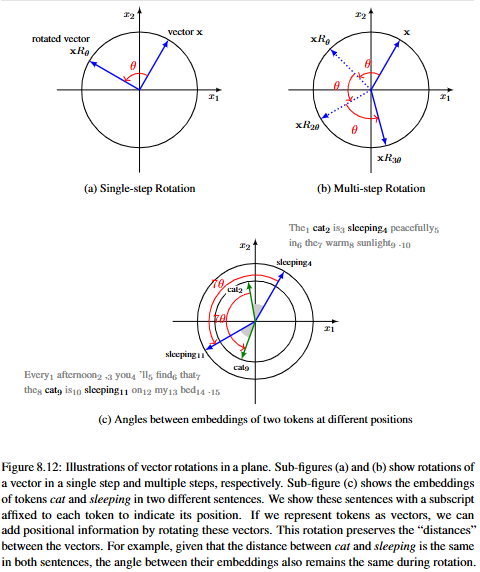

**Rotation 2D — góc $\theta$:**

$$\text{Ro}(x, \theta) = x R_\theta = [x_1\ x_2]\begin{bmatrix}\cos\theta & \sin\theta \\ -\sin\theta & \cos\theta\end{bmatrix} = [\cos\theta\cdot x_1 - \sin\theta\cdot x_2,\ \sin\theta\cdot x_1 + \cos\theta\cdot x_2] \tag{8.86}$$

**Multi-step rotation** — position $t$ = rotate $t$ lần:

$$\text{Ro}(x, t\theta) = x R_{t\theta} \tag{8.87}$$

**Biểu diễn qua complex numbers:**

$$x R_{t\theta} \mapsto x' e^{it\theta} = (x_1 + ix_2)(\cos t\theta + i\sin t\theta) \tag{8.88}$$

**Inner product — relative position tự nhiên:**

$$\langle C(x, t\theta), C(y, s\theta)\rangle = (x'\bar{y'})e^{i(t-s)\theta} \tag{8.89}$$

Kết quả phụ thuộc $t-s$ → **relative position được encode ngầm**.

**Dot-product trong Euclidean space:**

$$\text{Ro}(x, t\theta)[\text{Ro}(y, s\theta)]^\top = x R_{(t-s)\theta} y^\top \tag{8.90}$$

→ Self-attention với RoPE **tự động capture relative position** mà không cần thêm tham số!

**Tại sao RoPE bảo toàn semantic?** Rotation không thay đổi magnitude của vector → meaning của token được giữ nguyên, chỉ inject positional info.

**RoPE trong $d$ chiều** — xử lý $d/2$ cặp dimensions riêng biệt, mỗi cặp với frequency riêng:

$$\text{Ro}(x, t\theta) = [x_1\ \cdots\ x_d] \begin{pmatrix}R_{t\theta_1} & & \\ & \ddots & \\ & & R_{t\theta_{d/2}}\end{pmatrix} \tag{8.92}$$

với $\theta_k = 10000^{-2(k-1)/d}$ — tần số giảm dần theo $k$ (tương tự sinusoidal PE).

**Cài đặt thực tế** — chỉ dùng element-wise operations:

$$\text{Ro}(x, t\theta) = \begin{pmatrix}x_1\\\vdots\\x_d\end{pmatrix}^\top \odot \begin{pmatrix}\cos t\theta_1\\\cos t\theta_1\\\vdots\\\cos t\theta_{d/2}\\\cos t\theta_{d/2}\end{pmatrix}^\top + \begin{pmatrix}-x_2\\x_1\\\vdots\\-x_d\\x_{d-1}\end{pmatrix}^\top \odot \begin{pmatrix}\sin t\theta_1\\\sin t\theta_1\\\vdots\\\sin t\theta_{d/2}\\\sin t\theta_{d/2}\end{pmatrix}^\top \tag{8.93}$$

**Embedding cuối:**

$$e_i = \text{Ro}(x_i, i\theta) \tag{8.94}$$

### 3. Position Interpolation — Mở Rộng Context Length

**Vấn đề:** Train trên $[0, m_l]$ → inference cần $m > m_l$ → period của periodic functions không cover new positions tốt.

**Period của dimension $k$:**

$$\theta_k = b^{-2(k-1)/d} \quad \text{(8.97)}, \qquad T_k = 2\pi \cdot b^{2(k-1)/d} \quad \text{(8.98)}$$

**Linear Position Interpolation** — scale positions về $[0, m_l]$:

$$T'_k = \frac{m}{m_l} \cdot 2\pi \cdot b^{2(k-1)/d} \tag{8.99}$$

$$\text{Ro}'(x_i, i\theta) = \text{Ro}\!\left(x_i, \frac{m_l}{m} \cdot i\theta\right) \tag{8.100}$$

Chia position index cho $m/m_l$ → mọi vị trí trong $[0,m]$ map về $[0, m_l]$.

**NTK-aware Scaled RoPE** — scale base $b$ thay vì position:

Mục tiêu: period của highest frequency dimension khớp với linear interpolation:

$$2\pi(\lambda b)^{(d-2)/d} = \frac{m}{m_l} \cdot 2\pi \cdot b^{(d-2)/d} \tag{8.101}$$

Giải ra:

$$\lambda = \left(\frac{m}{m_l}\right)^{d/(d-2)} \tag{8.103}$$

$$\theta'_k = (\lambda b)^{-2(k-1)/d} \tag{8.105}$$

$$\text{Ro}'(x_i, i\theta) = \text{Ro}(x_i, i\theta') \tag{8.104}$$

**Tại sao NTK tốt hơn Linear Interpolation?**

| | Linear Interpolation | NTK-aware |
|---|---|---|
| Scaling | Uniform — mọi dimension chia cùng $m/m_l$ | Non-uniform — high-freq dims scale nhiều hơn |
| Local structure | Có thể làm mờ local patterns | Bảo toàn local structure tốt hơn |
| Extrapolation | Giới hạn trong $[0, m_l]$ | Flexible hơn |

---

## 8.3.6 Nhận Xét Tổng Quan

### 1. Nhu Cầu Long Context

**Mục tiêu cuối cùng:** LLMs xử lý **infinite context** — streaming data liên tục.

**Câu hỏi mở quan trọng:**
- Có thể compress infinite context vào model nhỏ không?
- Không phải tất cả context tokens đều cần thiết cho prediction — token nào quan trọng?
- Có thể biết trước contextual information nào cần không?

**Kết quả thú vị:** Deletang et al. (2024) — LLMs là **powerful in-context compressors** → kết nối với scaling laws. Pal et al. (2023), Wu et al. (2024) — internal features có thể predict tokens nhiều bước về tương lai, dù không được train tường minh cho điều đó.

### 2. Pre-training hay Adapting?

| Phương án | Ưu điểm | Nhược điểm |
|---|---|---|
| Pre-train từ đầu trên long seq | Kiến trúc tùy chọn | Cực kỳ tốn kém |
| Fine-tune pre-trained (RoPE/RPR) | Dùng off-the-shelf LLMs | Bị giới hạn bởi kiến trúc |
| Sparse attention fine-tuning | Pre-trained init cho params mới | Cần fine-tuning thêm |
| External memory (RAG) | Pre-trained LLM không đổi | Overhead retrieval |

### 3. Đánh Giá Long-context LLMs

**Needle-in-a-Haystack:** Giấu thông tin nhỏ trong văn bản dài → test LLM có retrieve được không.

**Passkey Retrieval:** Giấu passkey ngẫu nhiên → test exact recall từ long context.

**Copy Memory Tasks:** Yêu cầu LLM repeat lại đoạn text đã thấy — test từ recurrent models, nay dùng cho LLMs.

**Downstream tasks:** Long-doc summarization, long-doc QA, code completion → align với user expectations.

**Thách thức đánh giá:**
- Perplexity đo local context tốt hơn global → không đủ
- Prompt khác nhau → kết quả rất khác → khó isolate contribution của long-context
- Risk overclaiming — cải thiện có thể từ prompt engineering, không phải long-context modeling

---

## Tổng Kết Mục 8.3

```
Long Sequence Challenges: O(n²) + KV cache tăng tuyến tính

8.3.1 HPC:
  Mixed precision, FlashAttention
  Sequence parallelism: chia K,V → n_u nodes, all-reduce softmax

8.3.2 Efficient Architectures:
  Sparse: chỉ attend G ⊆ {0...i}  → giảm compute, vẫn cần full KV
  Linear: μᵢ = μᵢ₋₁ + k'ᵢᵀvᵢ → O(1), no KV cache
  Recurrent (Mamba): fixed-size state, linear complexity

8.3.3 Cache & Memory:
  Fixed-size: window, moving avg, cumulative avg, RNN, FIFO, Compressive
  External: k-NN attention, k-NN LM, RAG (retrieve → augment prompt)
  Trade-off: capacity vs computational cost

8.3.4 Sharing:
  MHA: O(L·τ·dh·m) — per-head K,V
  GQA: O(L·ng·dh·m) — ng groups share K,V  [LLaMA3: 32Q/8KV]
  MQA: O(L·dh·m) — all heads share K,V
  Cross-layer: share KV across layers

8.3.5 Positional Encoding for Long Sequences:
  Biases (extrapolation):
    T5: learned buckets ub(i-j)
    ALiBi: -β(i-j) linear, no params, good extrapolation
  RoPE (rotary):
    eᵢ = Ro(xᵢ, iθ)  → dot-product = xR_(t-s)θyᵀ
    Relative position ngầm trong self-attention
    θk = 10000^(-2(k-1)/d)
  Position Interpolation:
    Linear: Ro(xᵢ, (ml/m)·iθ) — uniform compress
    NTK-aware: scale base b → λ=(m/ml)^(d/(d-2)) — non-uniform
```